/tmp/ipykernel_3337/3068864567.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_3337/3068864567.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 


  Logistic Regression
  Accuracy : 0.7989
  Precision: 0.7797
  Recall   : 0.6667
  F1 Score : 0.7188
  ROC-AUC  : 0.8519

  Random Forest
  Accuracy : 0.8268
  Precision: 0.8065
  Recall   : 0.7246
  F1 Score : 0.7634
  ROC-AUC  : 0.8277

5-Fold CV ROC-AUC → LR: 0.853±0.022  RF: 0.869±0.025


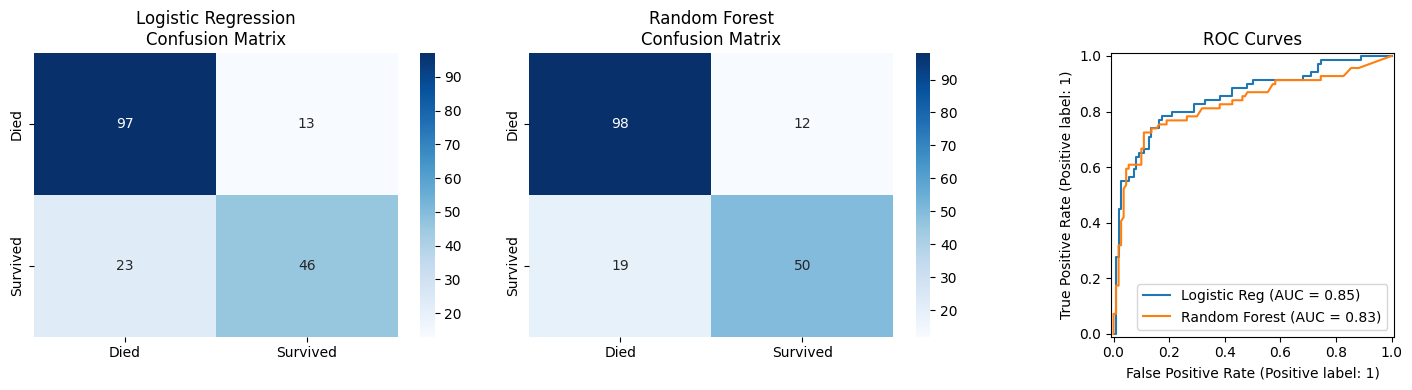

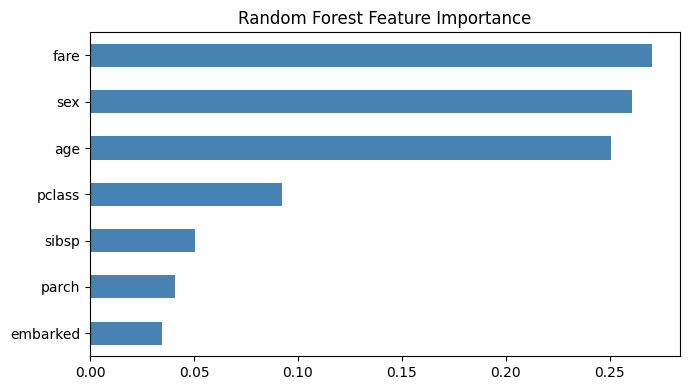


✅ Task 1 complete! Save this notebook as task1_classification.ipynb


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay)

# 1. Load & preprocess
df = sns.load_dataset('titanic')
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].copy()
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna('S', inplace=True)
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['embarked'] = LabelEncoder().fit_transform(df['embarked'])

X = df.drop('survived', axis=1)
y = df['survived']

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 3. Train models
lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train_sc, y_train)
rf.fit(X_train, y_train)

# 4. Evaluate
def evaluate(name, model, X_test, y_test, scaled=False):
    Xt = scaler.transform(X_test) if scaled else X_test
    y_pred = model.predict(Xt)
    y_prob = model.predict_proba(Xt)[:,1]
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    return y_pred, y_prob

lr_pred, lr_prob = evaluate("Logistic Regression", lr, X_test, y_test, scaled=True)
rf_pred, rf_prob = evaluate("Random Forest",       rf, X_test, y_test)

# 5. Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(lr, scaler.transform(X), y, cv=cv, scoring='roc_auc')
rf_cv = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC → LR: {lr_cv.mean():.3f}±{lr_cv.std():.3f}  "
      f"RF: {rf_cv.mean():.3f}±{rf_cv.std():.3f}")

# 6. Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrices
for ax, name, pred in zip(axes[:2],
    ['Logistic Regression','Random Forest'], [lr_pred, rf_pred]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
    ax.set_title(f'{name}\nConfusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, lr_prob, ax=axes[2], name='Logistic Reg')
RocCurveDisplay.from_predictions(y_test, rf_prob, ax=axes[2], name='Random Forest')
axes[2].set_title('ROC Curves')
plt.tight_layout()
plt.savefig('task1_results.png', dpi=120, bbox_inches='tight')
plt.show()

# 7. Feature importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', figsize=(7,4), color='steelblue')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('task1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Task 1 complete! Save this notebook as task1_classification.ipynb")